In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/Reviews.csv')

In [3]:
df.head(3)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [5]:
df.shape

(568454, 10)

In [6]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [7]:
df = df.dropna(subset=["ProfileName", "Summary"])

In [8]:
backup_df = df.copy()

In [9]:
def score_to_sentiment(score):
    if score<=2:
        return 'negative'
    elif score==3:
        return 'neutral'
    else:
        return 'positive'
    
df['score_sentiment'] = df['Score'].apply(score_to_sentiment)

In [10]:
#helpfulness ratio; if den==0 --> ratio=0 
df['helpfulness_ratio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1e-6)

#binary flag for “helpful” based on threshold
df['is_helpful'] = df['helpfulness_ratio'] >= 0.8

In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # keep letters and spaces only
    text = ' '.join(text.split())          # remove extra spaces
    return text

df['clean_text'] = df['Text'].apply(clean_text)

# Sentiment Analysis

In [12]:
pip install vaderSentiment

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df['vader_compound'] = df['clean_text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['vader_sentiment'] = df['vader_compound'].apply(
    lambda c: 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
)

In [14]:
print(df['vader_sentiment'].value_counts(normalize=True) * 100)

vader_sentiment
positive    87.815292
negative     9.876302
neutral      2.308406
Name: proportion, dtype: float64


In [15]:
df.head(1)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,score_sentiment,helpfulness_ratio,is_helpful,clean_text,vader_compound,vader_sentiment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive,0.999999,True,i have bought several of the vitality canned d...,0.9441,positive


In [16]:
import pandas as pd
print(pd.crosstab(df['score_sentiment'], df['vader_sentiment'])) #comparing with given scores

vader_sentiment  negative  neutral  positive
score_sentiment                             
negative            32712     4558     44737
neutral              7465     1698     33475
positive            15960     6865    420931


# Summarization

In [17]:
helpful_negative = df[(df['vader_sentiment'] == 'negative') & (df['is_helpful'])]
print(f"Number of helpful negative reviews: {len(helpful_negative)}")

Number of helpful negative reviews: 15765


In [18]:
helpful_positive = df[(df['vader_sentiment'] == 'positive') & (df['is_helpful'])]

In [30]:
pip install transformers torch

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
neg_texts = helpful_negative['Text'].tolist()

In [20]:
pos_texts = helpful_positive['Text'].tolist()

In [21]:
import random

#random seed for reproducibility
random.seed(42)

#100 reviews
sample_size = min(100, len(neg_texts))
sample_texts = random.sample(neg_texts, sample_size) if len(neg_texts) > sample_size else neg_texts

#combining them into one long string
combined_text = " ".join(sample_texts)
print(f"Summarizing {sample_size} reviews.")

Summarizing 100 reviews.


In [22]:
pos_sample_size = min(100, len(pos_texts))
sample_pos = random.sample(pos_texts, pos_sample_size) if len(pos_texts) > pos_sample_size else pos_texts
combined_pos = " ".join(sample_pos)

In [23]:
from transformers import pipeline

In [24]:
#loading the summarization pipeline (CPU)
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6", device=-1)

#truncate input to ~1024 tokens (approx 4000 chars) for token limit
max_input_chars = 4000
truncated_text = combined_text[:max_input_chars]

#generating summary
summary = summarizer(truncated_text, max_length=150, min_length=50, do_sample=False)[0]['summary_text']
print("\n--- AI Summary of Helpful Negative Reviews ---\n")
print(summary)

Device set to use cpu



--- AI Summary of Helpful Negative Reviews ---

 Switch Kiwi Berry is quite delicious, the flavor is very enjoyable . The flavor is what I would expect if Kool-aid could go bad . The only complaint is the addition of "natural flavors" which unfortunately is a very misleading term and can be very unhealthy substances .


In [25]:
max_chars = 4000
truncated_pos = combined_pos[:max_chars]
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6", device=-1)
summary_pos = summarizer(truncated_pos, max_length=150, min_length=50, do_sample=False)[0]['summary_text']

print("\n--- AI Summary of Helpful Positive Reviews ---\n")
print(summary_pos)

Device set to use cpu



--- AI Summary of Helpful Positive Reviews ---

 The Dandy Blend drink is a healthy substitute for coffee . PB2 Powdered Peanut Butter is 85% Less Fat and Calories - 6.5 Oz . I like the flavor of PB2, although it's not quite the same as peanut butter with fat .


In [26]:
with open('summary_positive.txt', 'w', encoding='utf-8') as f:
    f.write(summary_pos)

with open('summary_negative.txt', 'w', encoding='utf-8') as f:
    f.write(summary)   # assuming you saved the negative summary earlier

print("Both summaries saved.")

Both summaries saved.


In [27]:
from IPython.display import display, Markdown
display(Markdown(f"**Positive Summary:**\n\n{summary_pos}"))
display(Markdown(f"**Negative Summary:**\n\n{summary}"))

**Positive Summary:**

 The Dandy Blend drink is a healthy substitute for coffee . PB2 Powdered Peanut Butter is 85% Less Fat and Calories - 6.5 Oz . I like the flavor of PB2, although it's not quite the same as peanut butter with fat .

**Negative Summary:**

 Switch Kiwi Berry is quite delicious, the flavor is very enjoyable . The flavor is what I would expect if Kool-aid could go bad . The only complaint is the addition of "natural flavors" which unfortunately is a very misleading term and can be very unhealthy substances .

# Visualization

### Sentiment Distribution

In [28]:
pip install plotly

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import plotly.express as px

# Count of each sentiment
sentiment_counts = df['vader_sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

fig1 = px.bar(sentiment_counts, x='Sentiment', y='Count', color='Sentiment',
              title='VADER Sentiment Distribution (All Reviews)',
              text='Count')
fig1.update_traces(texttemplate='%{text}', textposition='outside')
# fig1.show()
# Optional: save as HTML
fig1.write_html('sentiment_distribution.html')

In [31]:
fig1_pie = px.pie(sentiment_counts, values='Count', names='Sentiment',
                  title='VADER Sentiment Distribution')
# fig1_pie.show()
fig1_pie.write_html('sentiment_distribution_pie.html')

### Word Cloud of Positive and Negative Comments

In [32]:
pip install wordcloud

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
  DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated pac

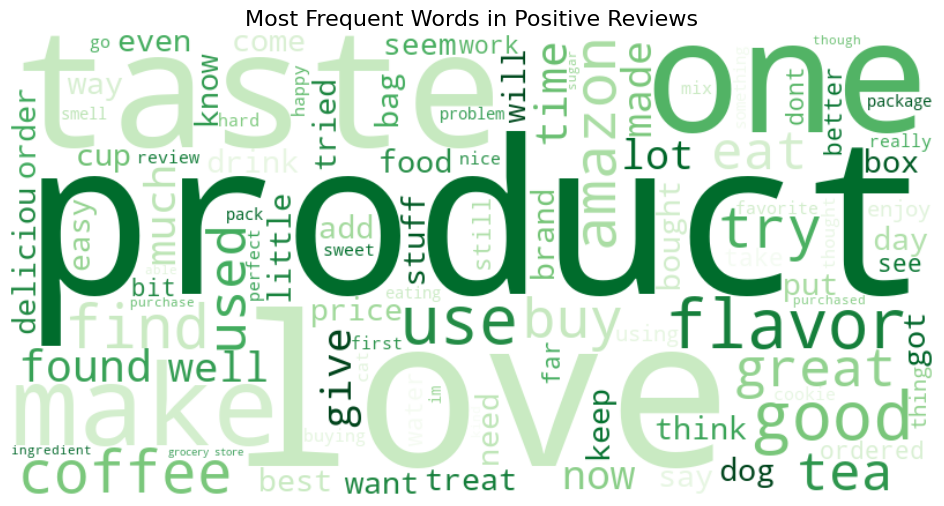

<Figure size 640x480 with 0 Axes>

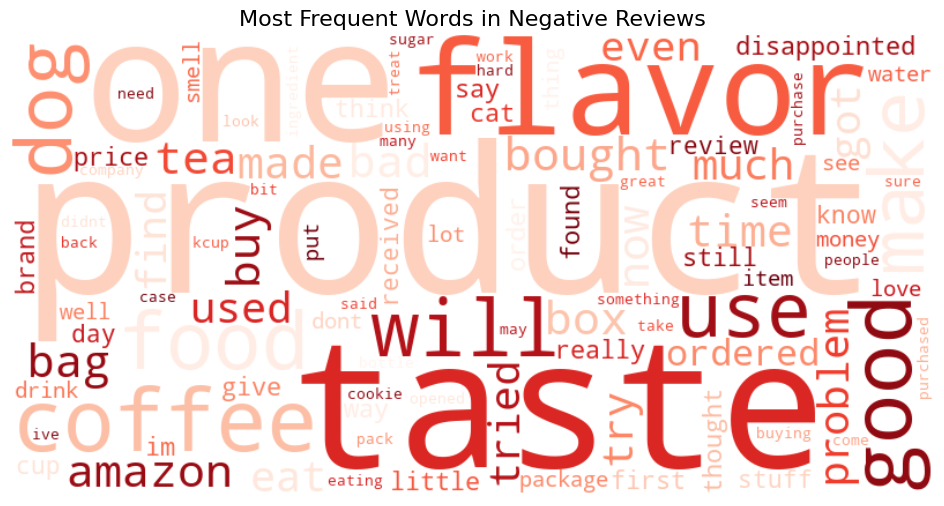

<Figure size 640x480 with 0 Axes>

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive reviews
positive_clean = " ".join(df[df['vader_sentiment'] == 'positive']['clean_text'])
wordcloud_positive = WordCloud(width=800, height=400, background_color='white',
                               max_words=100, colormap='Greens').generate(positive_clean)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews', fontsize=16)
plt.show()
# Save positive wordcloud
plt.savefig('wordcloud_positive.png', dpi=300, bbox_inches='tight')

# Negative reviews
negative_clean = " ".join(df[df['vader_sentiment'] == 'negative']['clean_text'])
wordcloud_negative = WordCloud(width=800, height=400, background_color='white',
                               max_words=100, colormap='Reds').generate(negative_clean)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews', fontsize=16)
plt.show()
plt.savefig('wordcloud_negative.png', dpi=300, bbox_inches='tight')

### Helpfulness Ratio Distribution

In [35]:
fig2 = px.histogram(df, x='helpfulness_ratio', nbins=50,
                    title='Distribution of Helpfulness Ratio',
                    labels={'helpfulness_ratio': 'Helpfulness Ratio'})
# fig2.show()
fig2.write_html('helpfulness_histogram.html')

In [36]:
helpful_counts = df['is_helpful'].value_counts().reset_index()
helpful_counts.columns = ['Is Helpful', 'Count']
fig3 = px.bar(helpful_counts, x='Is Helpful', y='Count', color='Is Helpful',
              title='Number of Helpful Reviews (ratio >= 0.8)')
# fig3.show()
fig3.write_html('helpful_reviews.html')

### VADER vs Score Sentiment

In [38]:
import plotly.graph_objects as go

# Your existing crosstab
comparison = pd.crosstab(df['score_sentiment'], df['vader_sentiment'])

fig4 = go.Figure(data=go.Heatmap(
    z=comparison.values,
    x=comparison.columns,
    y=comparison.index,
    colorscale='Blues',
    text=comparison.values,
    texttemplate='%{text}',
    textfont={"size":10},
    hoverongaps=False))
fig4.update_layout(title='Agreement between Rating Sentiment and VADER')
# fig4.show()
fig4.write_html('agreement.html')

In [41]:
agreement = (comparison.values[0,0] + comparison.values[1,1] + comparison.values[2,2]) / comparison.values.sum() * 100
print(f"Agreement: {agreement:.2f}%")

Agreement: 80.11%


In [40]:
fig = px.box(df, x='vader_sentiment', y='Score', 
             title='Star Rating Distribution by VADER Sentiment',
             labels={'vader_sentiment': 'VADER Sentiment', 'Score': 'Star Rating'})
# fig.show()
fig.write_html('box_score_vs_sentiment.html')

## Key Observations and Findings

### 1. Overall Sentiment Distribution (VADER)
87.8% of reviews are positive, 9.88% are negative, and 2.31% are neutral.

### 2. Agreement with Score Ratings
VADER and score ratings agree on ~80% of reviews. The disagreements could be due to the reviews containing a mixed sentiment or sarcasm.

### 3. Helpfulness
34.8% of reviews had a helpfulness ratio ≥ 0.8 (i.e., most users found them useful). Helpful reviews were more likely to be negative; this informs us which sentiment type is most valued by the community.

### 4. VADER vs Score
The box plot shows that reviews labeled negative by VADER have a median rating of 2, while positive VADER reviews have a median rating of 4. This aligns with expectations and validates VADER’s performance. However, there are some negative‑sentiment reviews still received high star ratings, often due to mixed feedback which pose as the outliers.
